In [1]:
import os 
import pandas as pd
from pathlib import Path 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
MASTER_DIR = Path(r"D:\Automotive\Race Strategy Decision Support System (RSDSS)\Race-Strategy-Decision-Support-System-RSDSS-\Data\Processed\Master\Master_Dataset.csv")
df = pd.read_csv(MASTER_DIR)

In [3]:
display(df.describe())

,Year,LapNumber,Position,LapTime_Seconds,TireAge,Stint,AirTemp,TrackTemp
count,98914.000000,98914.000000,98782.000000,97358.000000,97925.000000,98560.000000,98914.000000,98914.000000
mean,2023.594264,30.396162,9.759784,92.146065,14.428716,2.062003,23.881214,35.085293
std,1.099747,18.290718,5.409087,33.819578,10.358716,0.956740,4.836247,8.966965
min,2022.000000,1.000000,1.000000,67.012000,1.000000,1.000000,12.900000,15.600000
25%,2023.000000,15.000000,5.000000,81.668000,6.000000,1.000000,20.000000,29.000000
50%,2024.000000,29.000000,10.000000,89.890500,12.000000,2.000000,24.100000,34.200000
75%,2025.000000,45.000000,14.000000,99.198000,20.000000,3.000000,27.300000,42.600000
max,2025.000000,78.000000,20.000000,2526.253000,78.000000,8.000000,37.200000,57.500000


In [4]:
print(df["Driver"].nunique())

31


In [6]:
print(df["Team"].nunique())

13


In [7]:
print(df["Circuit"].nunique())

26


In [8]:
compound = df["Compound"].value_counts()

compound

Compound
HARD            43730
MEDIUM          35931
SOFT            12067
INTERMEDIATE     5945
WET               461
Name: count, dtype: int64

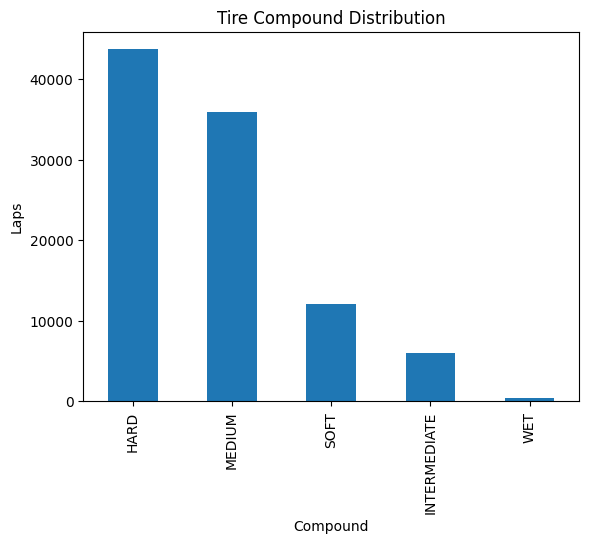

In [9]:
compound.plot(kind="bar")

plt.title("Tire Compound Distribution")
plt.ylabel("Laps")

plt.show()

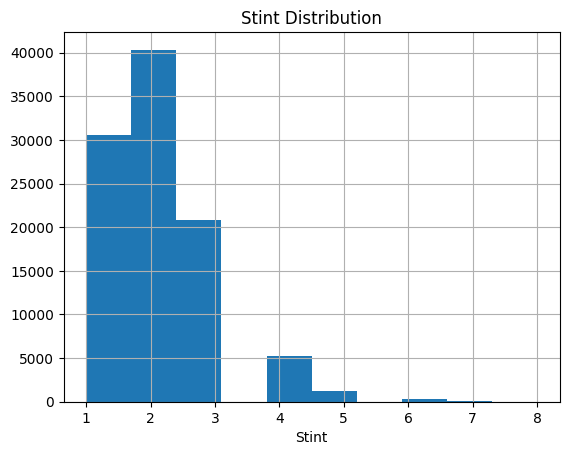

In [10]:
df["Stint"].hist(bins=10)

plt.title("Stint Distribution")
plt.xlabel("Stint")

plt.show()

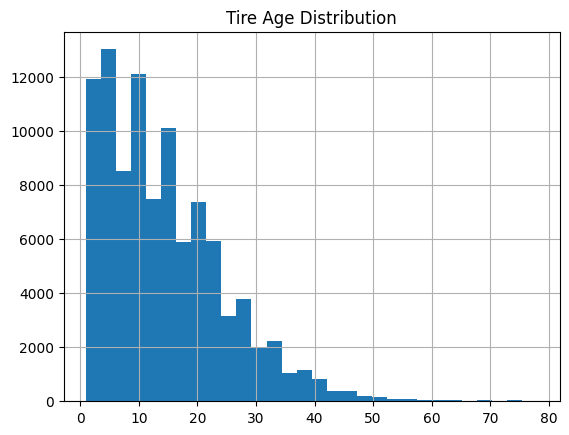

In [11]:
df["TireAge"].hist(bins=30)

plt.title("Tire Age Distribution")

plt.show()

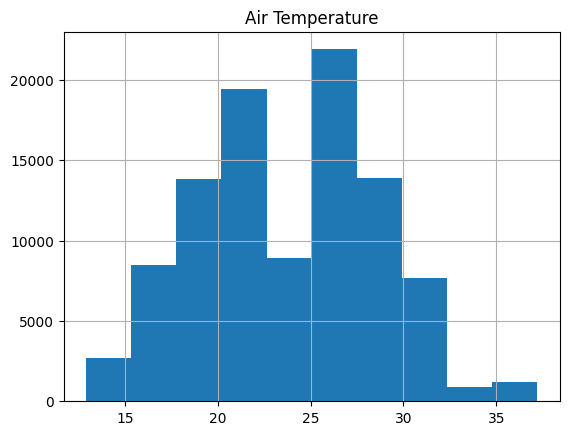

In [12]:
df["AirTemp"].hist()

plt.title("Air Temperature")

plt.show()

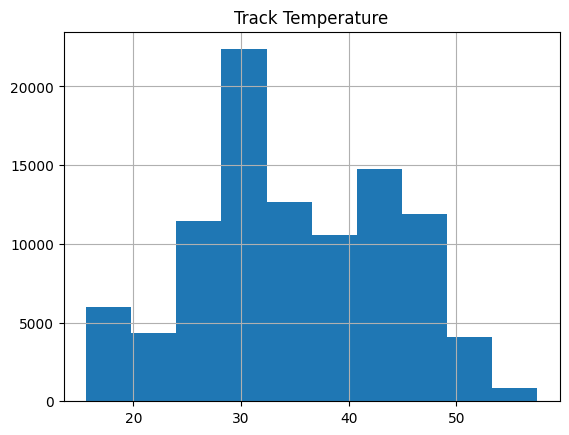

In [14]:
df["TrackTemp"].hist()

plt.title("Track Temperature")

plt.show()

In [15]:
laps = df.groupby("Driver").size()

laps.sort_values(ascending=False)

Driver
NOR    5291
VER    5234
RUS    5233
HAM    5098
LEC    4983
ALO    4956
GAS    4936
OCO    4870
STR    4855
TSU    4816
SAI    4749
ALB    4576
PIA    4024
HUL    3950
BOT    3603
PER    3540
ZHO    3525
MAG    3488
RIC    2553
LAW    1927
SAR    1917
BEA    1543
COL    1447
HAD    1344
ANT    1312
BOR    1233
LAT    1031
MSC    1016
VET     974
DEV     616
DOO     274
dtype: int64

In [16]:
laps = df.groupby("Team").size()

laps.sort_values()

Team
RB                  2606
Racing Bulls        2629
Alfa Romeo          4422
AlphaTauri          4562
Kick Sauber         5226
Williams            9223
Alpine              9640
Aston Martin        9869
Ferrari             9894
Haas F1 Team        9955
Red Bull Racing    10151
Mercedes           10283
McLaren            10454
dtype: int64

In [17]:
laps = df.groupby("Circuit").size()

laps.sort_values()

Circuit
Le Castellet          958
Miami Gardens        1005
Shanghai             2097
Las Vegas            2770
Lusail               3016
Miami                3306
Spa-Francorchamps    3328
Yas Island           3348
Suzuka               3353
São Paulo            3493
Jeddah               3562
Silverstone          3571
Imola                3577
Baku                 3794
Monza                3910
Melbourne            3973
Austin               4132
Sakhir               4438
Marina Bay           4439
Barcelona            5055
Mexico City          5139
Montréal             5202
Spielberg            5209
Monaco               5356
Budapest             5358
Zandvoort            5525
dtype: int64

In [18]:
df["LapTime_Seconds"].describe()

count    97358.000000
mean        92.146065
std         33.819578
min         67.012000
25%         81.668000
50%         89.890500
75%         99.198000
max       2526.253000
Name: LapTime_Seconds, dtype: float64

In [19]:
FIGURES_DIR = Path("../reports/eda/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

plt.savefig(FIGURES_DIR / "compound_distribution.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

## Conclusion 
- The dataset contains approximately 97,000 valid laps across four Formula 1 seasons.
- Most laps are completed on Hard, Medium, and Soft compounds.
- Track temperatures span a wide range, suggesting weather should be considered in the model.
- Tire age distribution indicates many stints end before the maximum tire life, reinforcing the importance of pit strategy.
- No unexpected missing values remain after cleaning.